# Forest inventory: learn and reproduce
This notebook reads the included, clipped historical inventory. Work through each step and explore a new threshold after reproducing the 90-year result. Source year: 2007. This is educational age screening, not allowable harvest determination.

The original-source spatial workflow is in `analyze.py`; review it to understand validity repair, clipping and area calculation.

In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT / "data/inventory.gpkg.zip").exists():
    raise FileNotFoundError("Open this notebook from the repository folder or set ROOT to that folder.")
import zipfile
if not (ROOT / "results/inventory.gpkg").exists():
    with zipfile.ZipFile(ROOT / "data/inventory.gpkg.zip") as archive:
        archive.extract("inventory.gpkg", ROOT / "results")
g = gpd.read_file(ROOT / "results/inventory.gpkg", layer="inventory")
print(f"Records: {len(g):,}; CRS: {g.crs}")
print(g[["POLYTYPE", "OAGE", "YRSOURCE", "area_ha"]].head().to_string(index=False))

Records: 3,581; CRS: EPSG:26917
POLYTYPE  OAGE  YRSOURCE  area_ha
     FOR    70      2007 1.412664
     WAT     0      2007 0.458272
     UCL     0      2007 2.590919
     WAT     0      2007 1.150529
     WAT     0      2007 0.709116


## 1. Inspect before analysing
Count records and area separately. A large polygon contributes more area than a small one. The package name does not establish the date of each observation.

In [2]:
print(g.groupby("POLYTYPE").agg(features=("area_ha", "size"), area_ha=("area_ha", "sum")).sort_values("area_ha", ascending=False).round(2))
print("Source years:", sorted(g.YRSOURCE.unique()))
print(g.groupby("age_flag").area_ha.sum())
assert abs(g.geometry.area.sum() / 10000 - g.area_ha.sum()) < 1e-6

          features   area_ha
POLYTYPE                    
FOR           2134  31063.52
UCL            303   3379.90
WAT            437   2917.97
OMS            467   1340.64
DAL             52    546.70
BSH             81    368.23
GRS             52    287.62
TMS             11     49.63
ISL             40     35.68
RCK              4     10.10
Source years: [np.int32(2007)]
age_flag
not_FOR     8936.476876
usable     31063.523124
Name: area_ha, dtype: float64


## 2. Use area-weighted age
Filter to FOR records with usable recorded ages. Do not add the years elapsed since 2007: harvesting and disturbance may have changed the forest.

In [3]:
forest = g[g["age_valid"].astype(bool)].copy()
weighted_age = (forest.age * forest.area_ha).sum() / forest.area_ha.sum()
print(f"Usable forest: {forest.area_ha.sum():,.2f} ha")
print(f"Area-weighted recorded age: {weighted_age:.2f} years")

Usable forest: 31,063.52 ha
Area-weighted recorded age: 76.99 years


## 3. Reproduce the four scenarios
These thresholds are disclosed teaching assumptions, not Ontario rules or species-specific maturity criteria.

In [4]:
rows = []
for threshold in [60, 80, 90, 100]:
    candidate = forest[forest.age >= threshold]
    rows.append({"threshold_years": threshold,
                 "candidate_area_ha": candidate.area_ha.sum(),
                 "pct_usable_forest": 100 * candidate.area_ha.sum() / forest.area_ha.sum()})
scenarios = pd.DataFrame(rows)
print(scenarios.round(2).to_string(index=False))
reference = pd.read_csv(ROOT / "results/scenarios.csv")
assert all(abs(scenarios.candidate_area_ha - reference.candidate_area_ha) < 1e-6)
assert scenarios.candidate_area_ha.is_monotonic_decreasing

 threshold_years  candidate_area_ha  pct_usable_forest
              60           27191.03              87.53
              80           19432.53              62.56
              90           11447.93              36.85
             100            3431.37              11.05


## 4. Your independent experiment
Change 90 to another age, rerun, and explain the change. What happens if the threshold is below every recorded age? Above every recorded age?

Age >= 90: 11,447.93 ha, 664 polygons


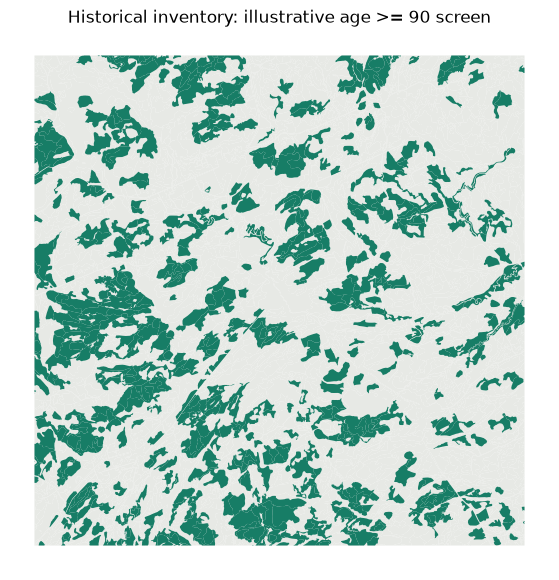

In [5]:
threshold = 90
candidate = forest[forest.age >= threshold]
print(f"Age >= {threshold}: {candidate.area_ha.sum():,.2f} ha, {len(candidate):,} polygons")
fig, ax = plt.subplots(figsize=(7, 7))
g.plot(ax=ax, color="#e7e9e5", linewidth=0)
candidate.plot(ax=ax, color="#177d66", linewidth=0)
ax.set_title(f"Historical inventory: illustrative age >= {threshold} screen")
ax.set_axis_off()
plt.show()

## 5. Verify a total using SQL
The SQLite file contains the same attributes, without geometries. SQL is useful for transparent summaries.

In [6]:
with sqlite3.connect(ROOT / "results/inventory.sqlite") as con:
    sql_total = con.execute("SELECT SUM(area_ha) FROM inventory WHERE age_valid=1 AND age>=80").fetchone()[0]
python_total = forest.loc[forest.age >= 80, "area_ha"].sum()
assert abs(sql_total - python_total) < 1e-6
print(f"SQL and Python agree: {sql_total:,.2f} ha")

SQL and Python agree: 19,432.53 ha


## Explain the limitations in your own words
1. Why is this not a forecast of current forest conditions?
2. What is missing before a polygon can be called operationally harvestable?
3. Why can repeated polygon IDs not automatically be deleted?
4. Why does an age-only rule fit uneven-aged stands poorly?
5. What would a multi-period wood-supply model need beyond these fields?

Read `results/report.html` and `QGIS_AND_INTERVIEW.md`. The QGIS exercise was completed: the applicant independently verified the 90-year scenario and exported age_screen_90.png.